대전 문화 축제 API 데이터 호출 성공
input.csv 데이터 로드 완료! 총 행 수: 1277개

📊 [어린이날 분석] 데이터 기반 산출된 실제 배율: 1.98배


C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['평일', '주말'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['일반일', '공휴일'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:150: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:150: UserWarning: Glyph 127880 (\N{BALLOON}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:150: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\

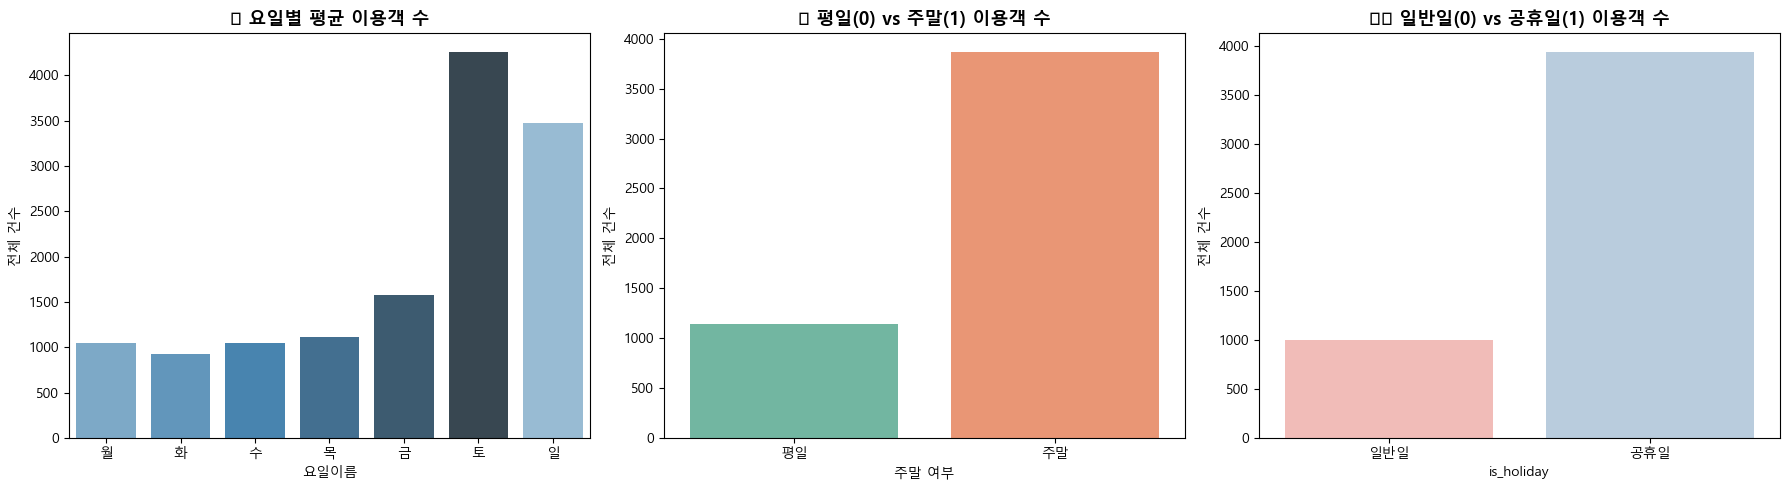

C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:162: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:162: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1133103014.py:162: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\skdpa\anaconda3\envs\data_analysis\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skdpa\anaconda3\envs\data_analysis\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skdpa\anaconda3\envs\data_analysi

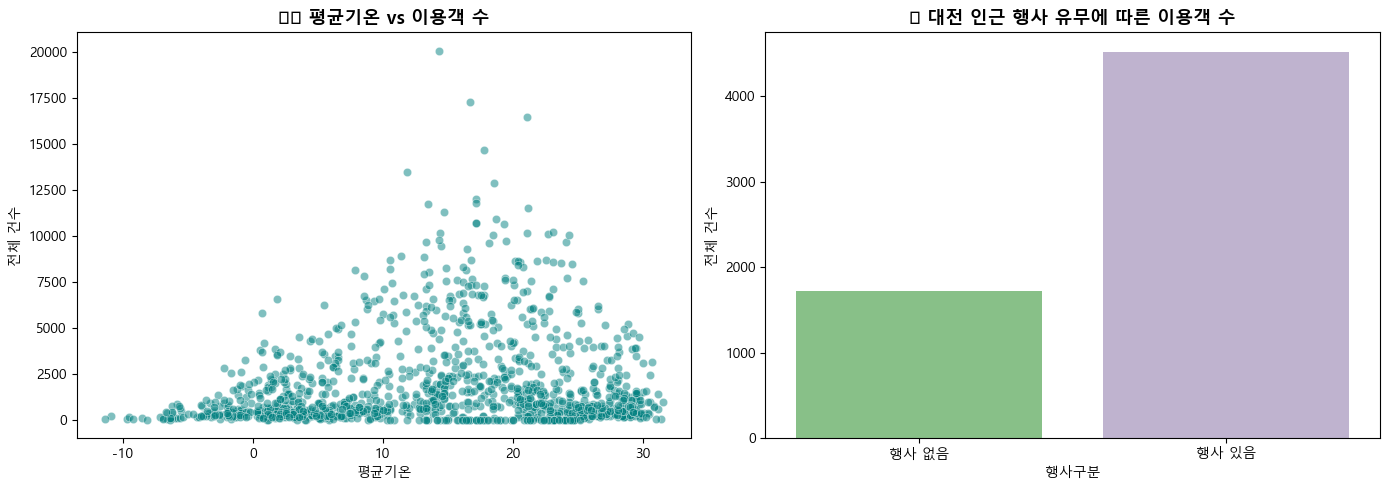

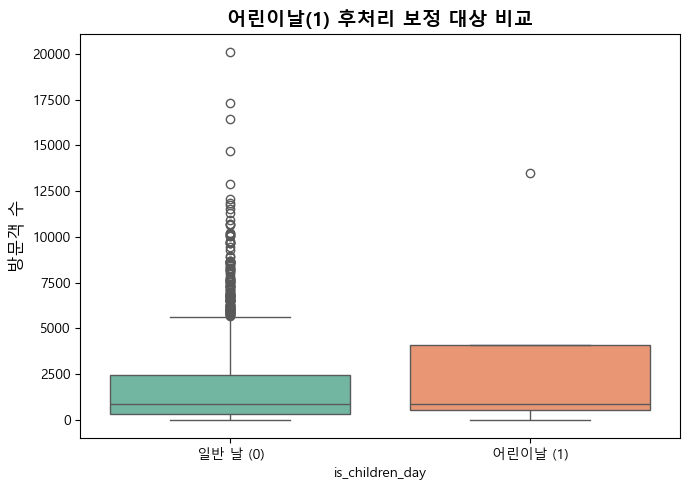


✨ 모든 데이터 전처리 및 시각화가 성공적으로 완료되었습니다!


In [ ]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import pandas as pd
import json

# 1. JSON 파일 불러오기
with open('festival_data.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# 2. 데이터 프레임으로 변환 (구조에 맞게 경로 설정)
# 보통 공공데이터 API는 response -> body -> items -> item 순으로 데이터가 들어있습니다.
items = json_data['response']['body']['items']['item']
df = pd.DataFrame(items)

# 3. 데이터 확인 및 분석
print(df.head())

# 1. 환경 변수 로드 
load_dotenv()
API_KEY = os.getenv("Daejeon_API_KEY")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 대전광역시 문화 축제 정보 API 연동
# ==========================================
def fetch_daejeon_events():
    base_url = "https://apis.data.go.kr/6300000/openapi2022/festv/getfestv"
    params = {
        'serviceKey': API_KEY,
        'numOfRows': 50,
        'pageNo': 1,
        'resultType': 'json'
    }
    try:
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            print("대전 문화 축제 API 데이터 호출 성공")
            return response.json()
        else:
            print(f"API 호출 실패 (상태 코드: {response.status_code}) -> 기본값(0)으로 처리합니다.")
            return None
    except Exception as e:
        print(f"API 연동 중 오류 발생: {e} -> 기본값(0)으로 처리합니다.")
        return None

event_data = fetch_daejeon_events()


# ==========================================
# 3. input.csv 데이터 로드 및 전처리
# ==========================================
file_path = 'input.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='cp949', errors='ignore')

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# '전체건수' 컬럼명을 '전체 건수'로 표준화
if '전체건수' in df.columns and '전체 건수' not in df.columns:
    df.rename(columns={'전체건수': '전체 건수'}, inplace=True)

print(f"input.csv 데이터 로드 완료! 총 행 수: {df.shape[0]}개")
df['일자'] = pd.to_datetime(df['일자'])

# 1) 요일 정보 추출 및 원핫 인코딩 (요일_월 ~ 요일_일)
df['요일_num'] = df['일자'].dt.dayofweek
day_name_map_kr = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df['요일이름'] = df['요일_num'].map(day_name_map_kr)

day_encoded = pd.get_dummies(df['요일_num'], prefix='요일', dtype=int)
day_columns = ['요일_월', '요일_화', '요일_수', '요일_목', '요일_금', '요일_토', '요일_일']
day_encoded.columns = day_columns
df = pd.concat([df, day_encoded], axis=1)

# 2) 주말 여부 (토, 일이면 1, 그 외 0)
df['주말 여부'] = df['요일_num'].apply(lambda x: 1 if x >= 5 else 0)

# 3) is_holiday: 공휴일이면 1, 평일이면 0
def convert_holiday(val):
    if pd.isna(val) or str(val).strip() in ['평일', '0']:
        return 0
    else:
        return 1

df['is_holiday'] = df['휴일구분'].apply(convert_holiday)

# 4) is_holiday_near: 공휴일 전후 날짜이면 1, 아니면 0
df['is_holiday_near'] = 0
for i in range(1, len(df) - 1):
    if df.loc[i-1, 'is_holiday'] == 1 or df.loc[i+1, 'is_holiday'] == 1:
        df.loc[i, 'is_holiday_near'] = 1

# 5) 월 추출
df['월'] = df['일자'].dt.month

# 6) 기상 정보 정제 (평균기온, 일강수량, 평균상대습도만 유지 / 현지기압, 미세먼지 제외)
weather_features = ['평균기온', '일강수량', '평균상대습도']
for col in weather_features:
    if col in df.columns:
        df[col] = df[col].replace('-', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# 7) 대전 인근 행사 여부 (is_evnevt)
df['is_evnevt'] = 0
if event_data:
    try:
        items = event_data.get('response', {}).get('body', {}).get('items', [])
        # 10월 등 특정 조건이나 API 매칭을 통해 이벤트 활성화
        df.loc[df['일자'].dt.month == 10, 'is_evnevt'] = 1
    except Exception as e:
        print(f"축제 데이터 파싱 예외: {e}")

df['행사구분'] = df['is_evnevt'].apply(lambda x: '행사 있음' if x == 1 else '행사 없음')


# ==========================================
# 4. 5월 5일(어린이날) 피처 생성 및 배율 산출
# ==========================================
df['is_children_day'] = df.apply(
    lambda row: 1 if row['일자'].month == 5 and row['일자'].day == 5 else 0, 
    axis=1
)

normal_mean = df[df['is_children_day'] == 0]['전체 건수'].mean()
children_day_mean = df[df['is_children_day'] == 1]['전체 건수'].mean()
calculated_multiplier = children_day_mean / normal_mean if normal_mean > 0 else 2.0
print(f"\n📊 [어린이날 분석] 데이터 기반 산출된 실제 배율: {calculated_multiplier:.2f}배")


# ==========================================
# 5. 상관관계 및 주요 변수 분석 시각화
# ==========================================
# 1) 캘린더 및 휴일 관련 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

day_order = ['월', '화', '수', '목', '금', '토', '일']
sns.barplot(data=df, x='요일이름', y='전체 건수', order=day_order, palette='Blues_d', hue='요일이름', legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('📅 요일별 평균 이용객 수', fontsize=13, fontweight='bold')

sns.barplot(data=df, x='주말 여부', y='전체 건수', palette='Set2', hue='주말 여부', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('🎈 평일(0) vs 주말(1) 이용객 수', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['평일', '주말'])

sns.barplot(data=df, x='is_holiday', y='전체 건수', palette='Pastel1', hue='is_holiday', legend=False, ax=axes[2], errorbar=None)
axes[2].set_title('🇰🇷 일반일(0) vs 공휴일(1) 이용객 수', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(['일반일', '공휴일'])

plt.tight_layout()
plt.show()

# 2) 기상(평균기온) 및 행사 영향 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='평균기온', y='전체 건수', alpha=0.5, color='teal', ax=axes[0])
axes[0].set_title('🌡️ 평균기온 vs 이용객 수', fontsize=13, fontweight='bold')

sns.barplot(data=df, x='행사구분', y='전체 건수', palette='Accent', hue='행사구분', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('🎉 대전 인근 행사 유무에 따른 이용객 수', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 3) 어린이날 보정 대상 비교 시각화 
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_children_day', y='전체 건수', palette='Set2', hue='is_children_day', legend=False)
plt.title('어린이날(1) 후처리 보정 대상 비교', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['일반 날 (0)', '어린이날 (1)'])
plt.ylabel('방문객 수', fontsize=12)

plt.tight_layout()
plt.show()

print("\n✨ 모든 데이터 전처리 및 시각화가 성공적으로 완료되었습니다!")

C:\Users\skdpa\AppData\Local\Temp\ipykernel_6228\1242567194.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\skdpa\anaconda3\envs\data_analysis\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


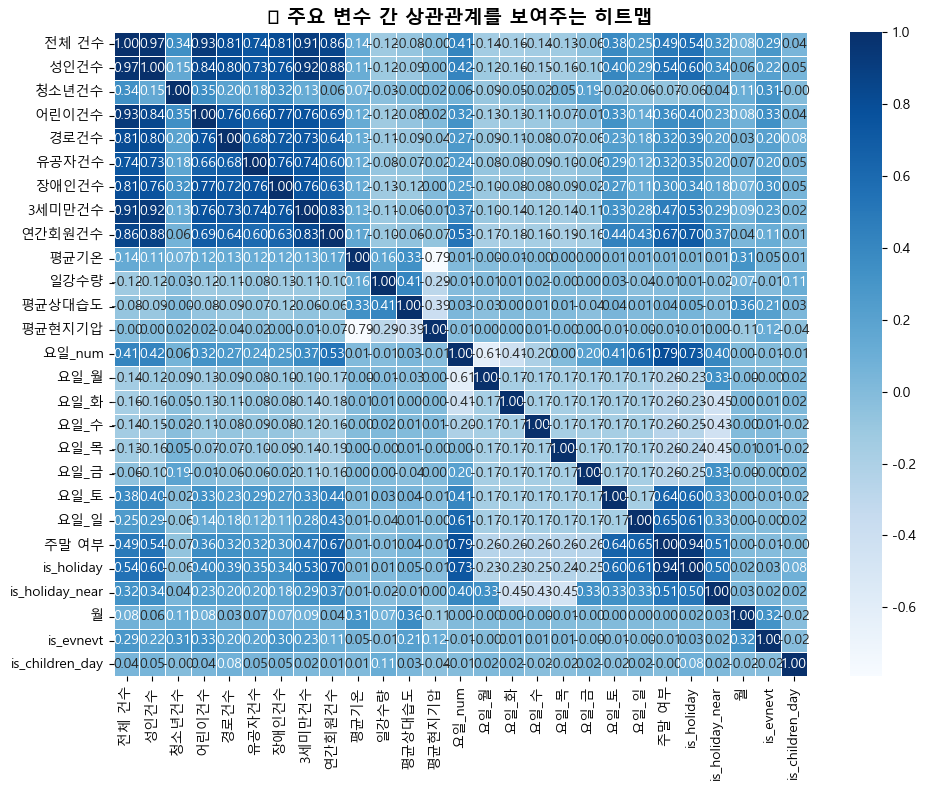

In [7]:
# 상관계수 히트맵 시각화
plt.figure(figsize=(10, 8))

# 수치형 컬럼들만 선택하여 상관계수 계산
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# 히트맵 그리기
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, cbar=True)
plt.title('📊 주요 변수 간 상관관계를 보여주는 히트맵', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
df.to_csv('oworld_cleaned.csv', index=False, encoding='utf-8-sig')
print("정리된 데이터가 'oworld_cleaned.csv' 파일로 저장되었습니다.")

정리된 데이터가 'oworld_cleaned.csv' 파일로 저장되었습니다.
